# Laboratorio 5 — Carga de datos y análisis exploratorio

**CC3084 · Ciencia de Datos · Universidad del Valle de Guatemala · Semestre II, 2026**

Este cuaderno cubre los **ejercicios 1, 2 y 5** del enunciado: la obtención del archivo
`train.csv`, su carga en Python y el análisis exploratorio del conjunto de datos.

El objetivo final del laboratorio es clasificar si un tweet se refiere a un desastre real
o no. Este cuaderno no entrena ningún modelo: su propósito es **entender los datos antes de
tocarlos**, y en particular producir las decisiones que el preprocesamiento (ejercicio 3) y
el modelado (ejercicio 6) van a necesitar justificar.

Cada bloque de resultados va acompañado de su interpretación. Las figuras se guardan en
`results/figures/` y las tablas en `results/tables/`, porque el informe las necesita como
archivos y no como salidas efímeras del cuaderno.

In [1]:
import sys
import re
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# El proyecto se importa como módulo para no repetir rutas ni constantes.
RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config
from carga import cargar_tweets, resumen

config.asegurar_directorios()

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 90)

def guardar(fig, nombre):
    """Guarda la figura en results/figures/ y devuelve la ruta."""
    ruta = config.FIGURES / nombre
    fig.savefig(ruta)
    print(f'figura guardada: {ruta.name}')
    return ruta

def guardar_tabla(df, nombre):
    """Guarda la tabla en results/tables/ y devuelve la ruta."""
    ruta = config.TABLES / nombre
    df.to_csv(ruta, index=True, encoding='utf-8')
    print(f'tabla guardada: {ruta.name}')
    return ruta

print('Entorno listo.')

Entorno listo.


## Ejercicios 1 y 2 — Obtención y carga de los datos

El archivo `train.csv` se obtiene con `python src/download_dataset.py`, que intenta la
descarga oficial desde Kaggle y verifica la huella SHA256 del archivo para garantizar que
todo el equipo trabaja sobre exactamente el mismo insumo.

La carga no se hace con un `read_csv` suelto sino a través de `src/carga.py`, que además
**valida** la estructura del archivo y **deduplica** según la regla acordada por el equipo.
Que todos los cuadernos usen la misma función es lo que hace comparables los resultados de
las tres personas.

In [2]:
df = cargar_tweets(deduplicar=True, verbose=True)
print()
print(f'Dimensiones finales: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(5)

Leído train.csv: 7,613 filas x 5 columnas
Deduplicación
  Filas originales................. 7,613
  Textos con etiqueta contradictoria 18 (55 filas eliminadas)
  Duplicados exactos eliminados.... 73
  Filas finales.................... 7,485 (128 eliminadas en total)

Dimensiones finales: 7,485 filas x 7 columnas


,id,keyword,location,text,target,n_palabras,n_caracteres
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,13,69
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,7,38
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other eva...,1,22,133
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1,8,65
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,16,88


### Por qué se deduplica, y por qué antes de partir

El archivo crudo trae 7,613 filas, pero 128 de ellas se eliminan por dos razones distintas
que conviene no mezclar:

- **18 textos aparecen con etiquetas contradictorias** (55 filas). El mismo tweet, palabra
  por palabra, está marcado a la vez como desastre y como no desastre. No existe criterio
  para decidir cuál anotación es la correcta, así que se eliminan todas sus filas. Su
  existencia es en sí misma un hallazgo: **ni siquiera los anotadores humanos coincidieron
  entre ellos**, lo que fija un techo al desempeño que cualquier modelo puede alcanzar.
- **73 filas son duplicados exactos con etiqueta consistente.** Se conserva la primera
  aparición.

El orden importa: la deduplicación ocurre **antes** de partir en entrenamiento y prueba. Si
se hiciera después, el mismo tweet podría quedar en ambos lados de la partición y el modelo
sería evaluado sobre textos que ya vio, inflando la métrica por una razón puramente
artificial.

In [3]:
tabla_resumen = resumen(df)
guardar_tabla(tabla_resumen, 'eda_resumen_columnas.csv')
tabla_resumen

tabla guardada: eda_resumen_columnas.csv


,tipo,nulos,% nulos,valores_unicos
id,int64,0,0.00,7485
keyword,str,56,0.75,221
location,str,2472,33.03,3321
text,str,0,0.00,7485
target,int64,0,0.00,2
n_palabras,int64,0,0.00,31
n_caracteres,int64,0,0.00,147


### Lectura de la estructura

Tres cosas quedan claras de la tabla anterior y condicionan todo lo que sigue:

- **`text` y `target` no tienen nulos.** El insumo esencial está completo: no hay que
  imputar nada en la variable de entrada ni en la respuesta.
- **`keyword` está casi completa** (0.75% de nulos) y tiene solo 221 valores distintos. Es
  una variable categórica de baja cardinalidad y buena cobertura: un predictor cómodo,
  siempre que aporte información. Se examina más abajo.
- **`location` tiene un tercio de nulos** (33.03%) y 3,321 valores distintos sobre 7,485
  filas. Esa combinación (muchos faltantes y altísima cardinalidad) anticipa una variable
  difícil de aprovechar.

`id` tiene tantos valores únicos como filas: es un identificador administrativo y **no debe
usarse como predictor**. Cualquier poder predictivo que mostrara sería un artefacto del
orden en que se armó el archivo.

## Ejercicio 5 — Análisis exploratorio

### 5.1 Distribución de la variable respuesta

La primera pregunta de cualquier problema de clasificación es cómo se reparten las clases,
porque de eso depende qué métrica tiene sentido usar.

tabla guardada: eda_distribucion_target.csv


figura guardada: eda_distribucion_target.png

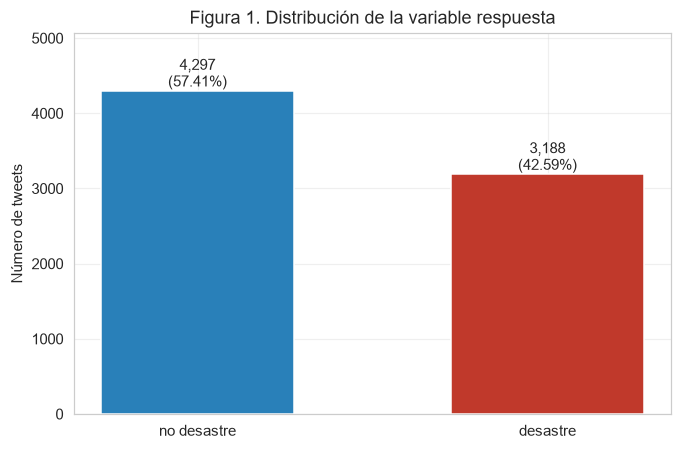

,frecuencia,porcentaje
target,,
no desastre,4297,57.41
desastre,3188,42.59


In [4]:
conteo = df.target.value_counts().sort_index()
porcentaje = (df.target.value_counts(normalize=True).sort_index() * 100).round(2)
dist = pd.DataFrame({'frecuencia': conteo, 'porcentaje': porcentaje})
dist.index = dist.index.map(config.ETIQUETAS)
guardar_tabla(dist, 'eda_distribucion_target.csv')

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(dist.index, dist.frecuencia,
                color=[config.COLOR_NO_DESASTRE, config.COLOR_DESASTRE], width=.55)
for barra, pct in zip(barras, dist.porcentaje):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 60,
            f'{int(barra.get_height()):,}\n({pct}%)', ha='center', fontsize=10)
ax.set_title('Figura 1. Distribución de la variable respuesta', fontsize=12)
ax.set_ylabel('Número de tweets')
ax.set_ylim(0, dist.frecuencia.max() * 1.18)
guardar(fig, 'eda_distribucion_target.png')
plt.show()
dist

**Interpretación.** El conjunto está desbalanceado de forma moderada: 57.41% de tweets que
no describen un desastre real frente a 42.59% que sí. No es el desbalance extremo que
haría inservible la exactitud, pero sí basta para volverla engañosa.

La consecuencia es concreta y hay que tenerla presente al leer el ejercicio 6: **un
clasificador que responda siempre "no desastre" acierta el 57.41% de las veces sin haber
aprendido nada.** Cualquier modelo debe compararse contra ese piso, no contra cero. Por eso
el laboratorio adopta **macro-F1** como métrica de selección, acompañada de precisión y
exhaustividad por clase y de la matriz de confusión, siguiendo el criterio del material del
curso para clases desbalanceadas.

### 5.2 Cruce de `keyword` con la variable respuesta

`keyword` es una palabra clave asociada al tweet, tomada de un catálogo cerrado. La pregunta
no es cuántas hay, sino **si separa las clases**. Se mide con la tasa de desastre de cada
keyword: la proporción de sus tweets que están etiquetados como desastre real.

In [5]:
# %20 es la codificación URL del espacio: viene así en el archivo original.
df['keyword_limpia'] = df.keyword.str.replace('%20', ' ', regex=False)

kw = (df.dropna(subset=['keyword_limpia'])
        .groupby('keyword_limpia')
        .agg(n_tweets=('target', 'size'), tasa_desastre=('target', 'mean'))
        .sort_values('tasa_desastre', ascending=False))
kw['tasa_desastre'] = kw.tasa_desastre.round(3)

print(f'Keywords distintas: {len(kw)}')
print(f'Tweets por keyword: mínimo {kw.n_tweets.min()}, mediana {int(kw.n_tweets.median())}, máximo {kw.n_tweets.max()}')
print(f'Keywords con tasa 100% desastre: {(kw.tasa_desastre == 1).sum()}')
print(f'Keywords con tasa 0% desastre:   {(kw.tasa_desastre == 0).sum()}')
guardar_tabla(kw, 'eda_keyword_tasa_desastre.csv')

top_d = kw.head(15)
top_n = kw.tail(15).sort_values('tasa_desastre')
pd.concat([top_d.assign(grupo='más asociadas a desastre'),
           top_n.assign(grupo='menos asociadas a desastre')])

Keywords distintas: 221
Tweets por keyword: mínimo 9, mediana 34, máximo 45
Keywords con tasa 100% desastre: 3
Keywords con tasa 0% desastre:   1
tabla guardada: eda_keyword_tasa_desastre.csv


,n_tweets,tasa_desastre,grupo
keyword_limpia,,,
derailment,33,1.000,más asociadas a desastre
debris,37,1.000,más asociadas a desastre
wreckage,37,1.000,más asociadas a desastre
outbreak,39,0.974,más asociadas a desastre
oil spill,38,0.974,más asociadas a desastre
typhoon,36,0.972,más asociadas a desastre
suicide bombing,32,0.969,más asociadas a desastre
suicide bomber,31,0.968,más asociadas a desastre
bombing,28,0.929,más asociadas a desastre


figura guardada: eda_keyword_tasa_desastre.png


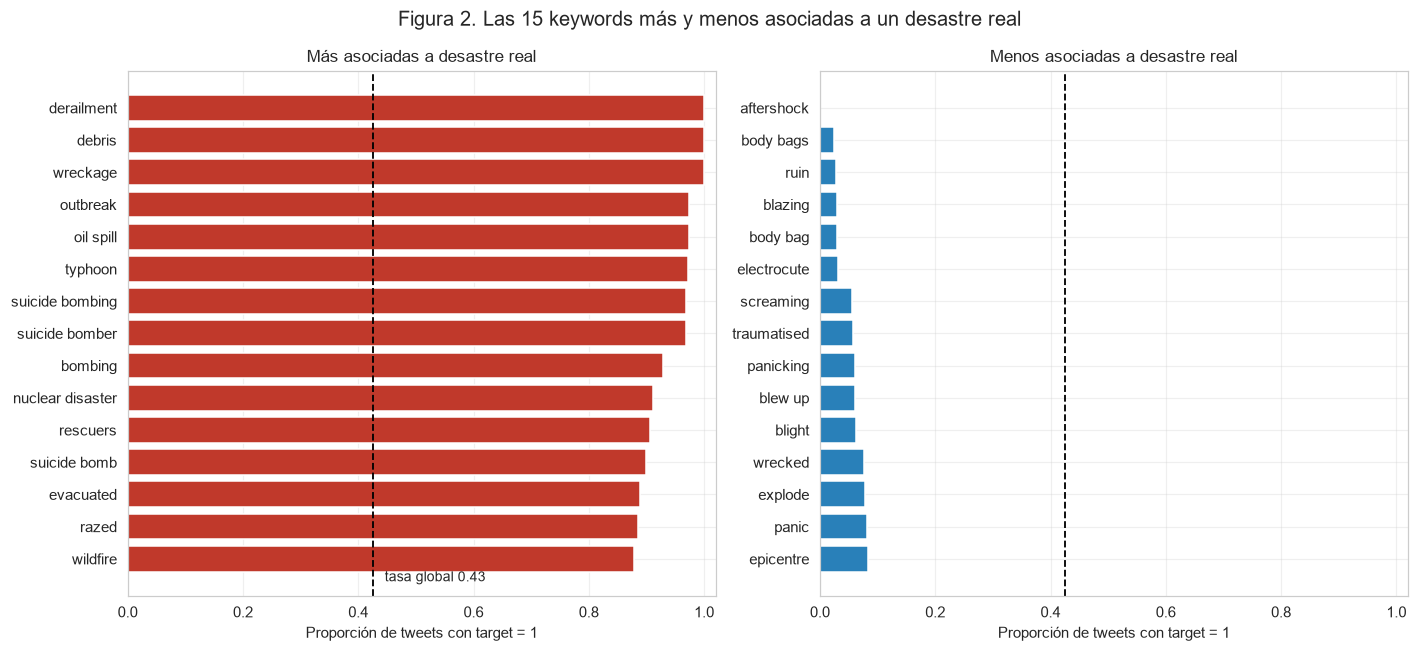

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True)

axes[0].barh(top_d.index[::-1], top_d.tasa_desastre[::-1], color=config.COLOR_DESASTRE)
axes[0].set_title('Más asociadas a desastre real', fontsize=11)
axes[0].set_xlabel('Proporción de tweets con target = 1')

axes[1].barh(top_n.index[::-1], top_n.tasa_desastre[::-1], color=config.COLOR_NO_DESASTRE)
axes[1].set_title('Menos asociadas a desastre real', fontsize=11)
axes[1].set_xlabel('Proporción de tweets con target = 1')

for ax in axes:
    ax.axvline(df.target.mean(), color='black', ls='--', lw=1.2)
    ax.set_xlim(0, 1.02)
axes[0].text(df.target.mean() + .02, -.7, f'tasa global {df.target.mean():.2f}', fontsize=9)

fig.suptitle('Figura 2. Las 15 keywords más y menos asociadas a un desastre real', fontsize=13)
fig.tight_layout()
guardar(fig, 'eda_keyword_tasa_desastre.png')
plt.show()

**Interpretación.** `keyword` es, con diferencia, la variable estructurada más informativa
del conjunto, y el hallazgo más útil de todo el análisis exploratorio.

Los extremos son casi deterministas. **`debris`, `derailment` y `wreckage` tienen tasa de
desastre del 100%**: cada uno de sus tweets describe un evento real. En el otro extremo,
**`aftershock` tiene tasa 0%**: ninguno de sus 32 tweets habla de una réplica sísmica real.
Ese contraste no es casual y explica el problema central del laboratorio.

La razón es el **uso figurado del lenguaje**. Palabras como `aftershock`, `ruin`, `blazing`,
`screaming` o `blew up` pertenecen al vocabulario de la catástrofe pero se usan de forma
cotidiana y metafórica ("the aftershock of that album", "this beat is blazing"). En cambio
`debris`, `derailment` o `wreckage` son términos técnicos que casi nadie emplea en sentido
figurado. **La dificultad del problema no está repartida de manera uniforme: se concentra
en el vocabulario que tiene doble vida.**

Dos consecuencias prácticas:

1. **`keyword` debería incorporarse como característica al modelo** del ejercicio 6, además
   del texto. Es información explícita, casi sin nulos y de baja cardinalidad, que el
   enunciado entrega gratis.
2. Los errores del clasificador deberían concentrarse en las keywords de tasa intermedia.
   Esa es una hipótesis verificable, y el análisis de errores del ejercicio 6 debería
   comprobarla.

Nota técnica: los espacios de las keywords vienen codificados como `%20` en el archivo
original (`oil%20spill`). Se decodifican antes de analizarlas; si no, la misma keyword se
trataría como un token ilegible.

### 5.3 Cruce de `location` con la variable respuesta

`location` es la ubicación desde la que se envió el tweet. A diferencia de `keyword`, no
proviene de un catálogo: es **texto libre que el usuario escribe en su perfil**, sin
validación de ningún tipo.

In [7]:
print(f'Nulos:            {df.location.isna().sum():,} ({df.location.isna().mean()*100:.2f}%)')
print(f'Valores distintos: {df.location.nunique():,} sobre {df.location.notna().sum():,} tweets con dato')
print(f'Valores que aparecen una sola vez: {(df.location.value_counts() == 1).sum():,}')
print()
print('Los 15 valores más frecuentes:')
top_loc = df.location.value_counts().head(15)
display(top_loc.to_frame('n_tweets'))

loc = (df.dropna(subset=['location'])
         .groupby('location')
         .agg(n_tweets=('target', 'size'), tasa_desastre=('target', 'mean')))
loc_frec = loc[loc.n_tweets >= 15].sort_values('tasa_desastre', ascending=False).round(3)
guardar_tabla(loc_frec, 'eda_location_tasa_desastre.csv')
print('\nUbicaciones con al menos 15 tweets, ordenadas por tasa de desastre:')
loc_frec

Nulos:            2,472 (33.03%)
Valores distintos: 3,321 sobre 5,013 tweets con dato
Valores que aparecen una sola vez: 2,813

Los 15 valores más frecuentes:


,n_tweets
location,
USA,104
New York,71
United States,50
London,45
Canada,29
UK,26
"Los Angeles, CA",26
Nigeria,23
India,21


tabla guardada: eda_location_tasa_desastre.csv

Ubicaciones con al menos 15 tweets, ordenadas por tasa de desastre:


,n_tweets,tasa_desastre
location,,
Mumbai,20,0.900
India,21,0.810
Nigeria,23,0.739
"Washington, DC",21,0.714
USA,104,0.644
Worldwide,19,0.632
UK,26,0.577
United States,50,0.540
"California, USA",15,0.533


**Interpretación.** `location` es una variable de mala calidad y el análisis lo muestra con
claridad:

- **Un tercio de los tweets no la tiene** (33.03% de nulos).
- **No está normalizada.** `USA`, `United States` y `New York` conviven como valores
  distintos aunque se solapen conceptualmente; lo mismo pasa con `UK` y `London`. El mismo
  lugar aparece escrito de varias formas y cada variante ocupa una categoría propia.
- **Su cardinalidad es altísima**: 3,321 valores distintos, y la gran mayoría aparece una
  sola vez. Una categoría que aparece una vez no permite estimar nada.
- Al ser texto libre, contiene entradas que **no son lugares en absoluto**.

**Decisión para el modelado:** `location` se descarta como predictor. Convertirla en algo
útil exigiría geocodificación y normalización, un esfuerzo que excede el alcance del
laboratorio y que difícilmente compensaría dado el 33% de faltantes. Se documenta la
decisión con esta evidencia en lugar de simplemente omitir la variable.

Este contraste con `keyword` es instructivo: dos columnas categóricas del mismo archivo, una
utilísima y la otra inservible. Lo que las separa no es el tema sino **el proceso que las
generó**: una viene de un catálogo cerrado, la otra de un campo de texto libre.

### 5.4 Longitud de los tweets

El enunciado pide histogramas. La pregunta concreta: ¿los tweets que describen desastres
reales se escriben distinto en cuanto a extensión?

In [8]:
long_stats = df.groupby('target')[['n_palabras', 'n_caracteres']].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
long_stats.index = long_stats.index.map(config.ETIQUETAS)
guardar_tabla(long_stats, 'eda_longitud_por_clase.csv')
display(long_stats)

for col in ['n_palabras', 'n_caracteres']:
    u, p = mannwhitneyu(df.loc[df.target == 1, col], df.loc[df.target == 0, col])
    print(f'{col:14s} Mann-Whitney U = {u:,.0f}   p = {p:.2e}')

tabla guardada: eda_longitud_por_clase.csv


n_palabras                      n_caracteres                       
                  mean median   std min max         mean median    std min  max
target                                                                         
no desastre      14.67   15.0  6.16   1  31        95.58  101.0  35.94   7  157
desastre         15.14   15.0  5.09   2  30       108.02  114.0  29.27  14  151

n_palabras     Mann-Whitney U = 7,190,262   p = 2.23e-04
n_caracteres   Mann-Whitney U = 8,155,566   p = 2.43e-45


figura guardada: eda_longitud_histogramas.png


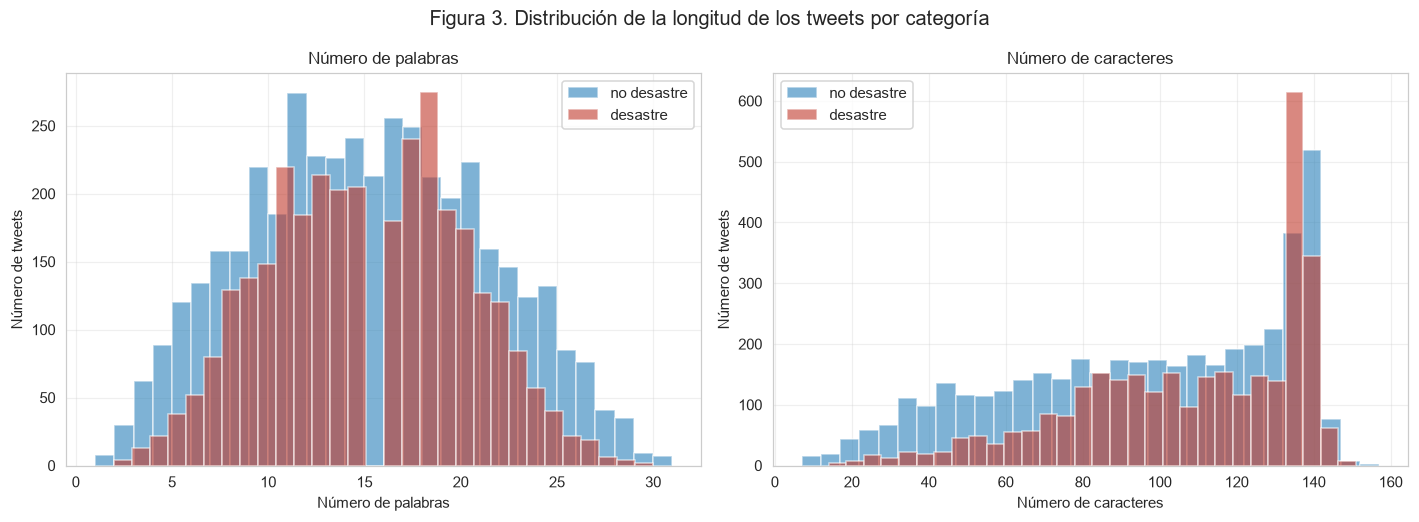

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, col, titulo in zip(axes,
                           ['n_palabras', 'n_caracteres'],
                           ['Número de palabras', 'Número de caracteres']):
    for tgt in [0, 1]:
        ax.hist(df.loc[df.target == tgt, col], bins=30, alpha=.6,
                label=config.ETIQUETAS[tgt], color=config.COLORES_CLASE[tgt])
    ax.set_xlabel(titulo)
    ax.set_ylabel('Número de tweets')
    ax.set_title(titulo, fontsize=11)
    ax.legend()

fig.suptitle('Figura 3. Distribución de la longitud de los tweets por categoría', fontsize=13)
fig.tight_layout()
guardar(fig, 'eda_longitud_histogramas.png')
plt.show()

**Interpretación.** Las dos medidas de longitud cuentan historias distintas, y la diferencia
entre ellas es lo interesante.

En **número de palabras** la diferencia es mínima: 15.14 palabras de media en los tweets de
desastre frente a 14.67 en los demás. Menos de media palabra.

En **número de caracteres** la diferencia es mucho mayor: 108.0 frente a 95.6, unos 12
caracteres. La comparación de los valores p lo confirma: el contraste en caracteres
(p ≈ 2×10⁻⁴⁵) es de un orden de magnitud completamente distinto al de palabras
(p ≈ 2×10⁻⁴).

**Un tweet de desastre tiene prácticamente el mismo número de palabras, pero esas palabras
son más largas.** Dos explicaciones compatibles: los tweets de desastre incluyen URLs con
mucha más frecuencia (se verifica en la sección siguiente) y emplean vocabulario técnico
más extenso (`derailment`, `evacuation`, `catastrophe`) frente al registro coloquial y de
palabras cortas del resto.

Advertencia sobre la lectura de estos valores p: con 7,485 observaciones casi cualquier
diferencia resulta estadísticamente significativa. Lo que importa no es que el valor p sea
pequeño, sino que **la diferencia en caracteres es lo bastante grande como para ser
aprovechable**, mientras que la de palabras, aun siendo significativa, es demasiado pequeña
para resultar útil por sí sola.

### 5.5 Patrones de escritura: URLs, menciones, hashtags, números y emoticones

Esta sección existe para alimentar decisiones concretas del **ejercicio 3**. El enunciado
propone quitar URLs, menciones, símbolos, números y emoticones. Antes de borrar nada
conviene medir **cuánta señal se estaría tirando**, porque lo que es ruido para una tarea
puede ser la señal de otra.

In [10]:
patrones = {
    'Contiene URL':            r'https?://\S+|www\.\S+',
    'Contiene mención (@)':    r'@\w+',
    'Contiene hashtag (#)':    r'#\w+',
    'Contiene entidad HTML':   r'&(amp|gt|lt|quot);',
    'Contiene algún dígito':   r'\d',
    'Contiene MAYÚSCULAS':     r'\b[A-Z]{3,}\b',
    'Contiene exclamación':    r'!',
}

filas = []
for nombre, patron in patrones.items():
    tiene = df.text.str.contains(patron, regex=True, na=False)
    filas.append({
        'patron': nombre,
        'global_%': tiene.mean() * 100,
        'no_desastre_%': tiene[df.target == 0].mean() * 100,
        'desastre_%': tiene[df.target == 1].mean() * 100,
    })

pat = pd.DataFrame(filas).set_index('patron')
pat['diferencia_pp'] = pat['desastre_%'] - pat['no_desastre_%']
pat = pat.round(2)
guardar_tabla(pat, 'eda_patrones_texto.csv')
pat

tabla guardada: eda_patrones_texto.csv


C:\Users\User\AppData\Local\Temp\ipykernel_40152\673497770.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tiene = df.text.str.contains(patron, regex=True, na=False)


,global_%,no_desastre_%,desastre_%,diferencia_pp
patron,,,,
Contiene URL,52.64,41.73,67.35,25.62
Contiene mención (@),26.64,31.07,20.67,-10.40
Contiene hashtag (#),22.62,20.13,25.97,5.84
Contiene entidad HTML,4.77,5.14,4.27,-0.88
Contiene algún dígito,59.63,49.90,72.74,22.85
Contiene MAYÚSCULAS,19.52,18.20,21.30,3.10
Contiene exclamación,9.45,11.99,6.02,-5.96


figura guardada: eda_patrones_texto.png

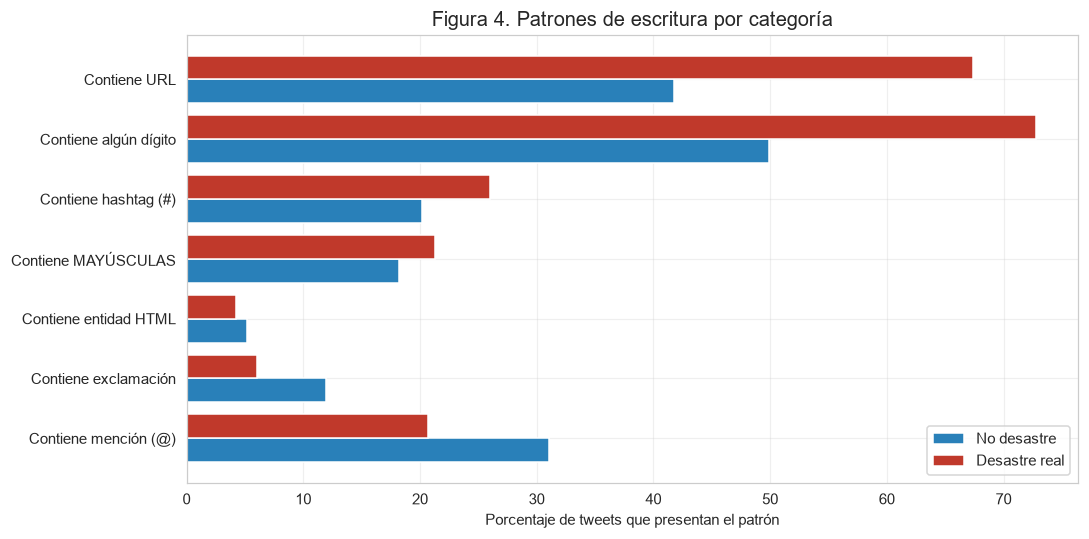

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
orden = pat.sort_values('diferencia_pp')
y = np.arange(len(orden))
ax.barh(y - .2, orden['no_desastre_%'], height=.4,
        label='No desastre', color=config.COLOR_NO_DESASTRE)
ax.barh(y + .2, orden['desastre_%'], height=.4,
        label='Desastre real', color=config.COLOR_DESASTRE)
ax.set_yticks(y)
ax.set_yticklabels(orden.index)
ax.set_xlabel('Porcentaje de tweets que presentan el patrón')
ax.set_title('Figura 4. Patrones de escritura por categoría', fontsize=13)
ax.legend()
fig.tight_layout()
guardar(fig, 'eda_patrones_texto.png')
plt.show()

**Interpretación.** Dos patrones separan las clases con fuerza, y ambos son justamente los
que el enunciado sugiere eliminar.

**Las URLs son el patrón más discriminativo del conjunto.** Aparecen en el 67.35% de los
tweets de desastre frente al 41.73% de los demás: **25.6 puntos porcentuales de diferencia**.
Tiene sentido, porque un tweet sobre un evento real suele enlazar la noticia que lo
respalda. Esto obliga a un matiz importante en el ejercicio 3: *el texto* de una URL es
ruido (`http://t.co/k4zoMOF319` no aporta nada y además infla el vocabulario con un token
irrepetible), pero *el hecho de que haya una URL* es señal valiosa. **La recomendación al
preprocesamiento es sustituir cada URL por un token uniforme en lugar de borrarla**, de modo
que se elimine el ruido y se conserve la información.

**Los dígitos siguen el mismo patrón:** 72.74% frente a 49.90%, casi 23 puntos de
diferencia. Los tweets de desastre están llenos de magnitudes, fechas, número de víctimas y
números de carretera. **Eliminar los números a ciegas destruiría señal real.**

Sobre el `911` que el enunciado sugiere considerar: aparece en **solo 4 tweets** de los
7,485. Es anecdótico. La verificación es útil porque corrige la intuición: lo que hay que
conservar no es un número concreto sino **los números en general**, que es donde está la
señal.

En dirección contraria, las **menciones** (31.07% frente a 20.67%) y las **exclamaciones**
(11.99% frente a 6.02%) son más frecuentes en los tweets que **no** son de desastre. Encajan
con un registro conversacional y emocional, frente al tono informativo y factual de los
tweets que reportan eventos reales. **Ese hallazgo anticipa un resultado del ejercicio 10**:
si los tweets de desastre son más factuales y menos emocionales, una variable de sentimiento
podría no ser tan útil para distinguirlos como parecería a primera vista.

In [12]:
# El enunciado pide revisar si hay emoticones. Conviene medirlo antes de decidir.
sin_url = df.text.str.replace(r'https?://\S+|www\.\S+', '', regex=True)
patron_emoticon = r'(?<![A-Za-z0-9])[:;=][-o\*\']?[\)\(\]\[dDpP/\\\|3](?![0-9])|<3'
tiene_emoticon = sin_url.str.contains(patron_emoticon, regex=True, na=False)

patron_emoji = r'[\U0001F300-\U0001FAFF\u2600-\u27BF]'
tiene_emoji = df.text.str.contains(patron_emoji, regex=True, na=False)

patron_mojibake = r'[\x80-\x9F]|\u00DB'
tiene_mojibake = df.text.str.contains(patron_mojibake, regex=True, na=False)

print(f'Emojis Unicode:            {tiene_emoji.sum():>5,} tweets ({tiene_emoji.mean()*100:.2f}%)')
print(f'Emoticones ASCII (:-) :D): {tiene_emoticon.sum():>5,} tweets ({tiene_emoticon.mean()*100:.2f}%)')
print(f'  tasa de desastre en ellos: {df[tiene_emoticon].target.mean():.3f} '
      f'(global: {df.target.mean():.3f})')
print(f'Caracteres corruptos:      {tiene_mojibake.sum():>5,} tweets ({tiene_mojibake.mean()*100:.2f}%)')
print()
print('Ejemplos de texto con caracteres corruptos:')
for t in df.loc[tiene_mojibake, 'text'].head(3):
    print('  ', repr(t[:95]))

Emojis Unicode:                0 tweets (0.00%)

Emoticones ASCII (:-) :D):    71 tweets (0.95%)
  tasa de desastre en ellos: 0.169 (global: 0.426)
Caracteres corruptos:        591 tweets (7.90%)

Ejemplos de texto con caracteres corruptos:
   'Barbados #Bridgetown JAMAICA \x89ÛÒ Two cars set ablaze: SANTA CRUZ \x89ÛÓ Head of the St Elizabeth P'
   'SANTA CRUZ \x89ÛÓ Head of the St Elizabeth Police Superintendent Lanford Salmon has r ... - http:/'
   'Set our hearts ablaze and every city was a gift And every skyline was like a kiss upon the lips'


**Interpretación: la pregunta de los emoticones tiene una respuesta empírica.**

El enunciado pide revisar si hay emoticones y quitarlos (ejercicio 3), y más adelante
pregunta si valdrá la pena conservarlos para analizarlos (ejercicio 8). La medición
responde las dos preguntas de golpe:

- **No hay ni un solo emoji Unicode en el corpus** (0.00%).
- **Los emoticones ASCII aparecen en apenas el 0.94% de los tweets** (70 de 7,485).
- En cambio, **el 7.90% de los tweets contiene caracteres corruptos**: secuencias como
  `\x89ÛÏ` que no son emojis sino **mojibake**, texto Unicode mal decodificado al construir
  el archivo original. Con toda probabilidad *ahí* estuvieron los emojis: se destruyeron
  antes de que el conjunto llegara a nosotros.

**Consecuencias.** Para el ejercicio 3, no hace falta un tratamiento sofisticado de
emoticones porque casi no existen; lo que sí hace falta es **limpiar el mojibake**, que
afecta a ocho veces más tweets y produce tokens basura. Para el ejercicio 8, la respuesta a
"¿valdrá la pena dejar los emoticones y analizarlos?" es **no en este corpus**, y la razón
es la ausencia de material, no una decisión de diseño.

Vale la pena señalar el matiz: los 70 tweets que sí tienen emoticón muestran una tasa de
desastre del 17.1%, muy por debajo del 42.6% global. Es coherente con todo lo anterior
—quien escribe `:)` no está reportando una catástrofe— pero con 70 casos la base es
demasiado pequeña para sostener una conclusión firme.

### 5.6 Palabras más frecuentes en cada categoría

El enunciado pide investigar qué palabra se repite más en cada categoría y presentar un
histograma de las más frecuentes.

**Nota sobre el alcance.** Esta sección usa una tokenización provisional definida aquí
mismo, cuyo único fin es sostener este análisis exploratorio y las nubes de palabras. El
preprocesamiento formal (ejercicio 3) y el análisis riguroso de frecuencias, probabilidades
y n-gramas (ejercicio 4) viven en `02_preprocesamiento.ipynb` y `03_ngramas.ipynb`.

In [13]:
STOPWORDS = set('''
a about above after again against all am an and any are aren as at be because been before
being below between both but by can cannot could couldn did didn do does doesn doing don
down during each few for from further had hadn has hasn have haven having he her here hers
herself him himself his how i if in into is isn it its itself just ll me more most my myself
no nor not now of off on once only or other our ours ourselves out over own re s same shan
she should shouldn so some such t than that the their theirs them themselves then there
these they this those through to too under until up ve very was wasn we were weren what
when where which while who whom why will with won would you your yours yourself yourselves
im dont amp via rt get like one got new
'''.split())

def tokenizar_provisional(texto):
    """Tokenización mínima SOLO para este análisis exploratorio.
    El pipeline formal es responsabilidad del ejercicio 3."""
    t = re.sub(r'https?://\S+|www\.\S+', ' ', texto.lower())
    t = re.sub(r'@\w+', ' ', t)
    t = re.sub(r'&\w+;', ' ', t)
    t = re.sub(r'[^a-z0-9 ]', ' ', t)
    return [w for w in t.split() if w not in STOPWORDS and len(w) > 2]

frec = {}
for tgt in [0, 1]:
    contador = collections.Counter(
        w for texto in df.loc[df.target == tgt, 'text'] for w in tokenizar_provisional(texto))
    frec[tgt] = contador
    print(f'{config.ETIQUETAS[tgt]:12s}: {sum(contador.values()):,} tokens, '
          f'{len(contador):,} palabras distintas')
    print(f'  palabra más repetida: "{contador.most_common(1)[0][0]}" '
          f'({contador.most_common(1)[0][1]} veces)')

top_frec = pd.DataFrame({
    'desastre': pd.Series(dict(frec[1].most_common(20))),
    'no_desastre': pd.Series(dict(frec[0].most_common(20))),
})
guardar_tabla(top_frec, 'eda_top_palabras_por_clase.csv')
top_frec

no desastre : 33,279 tokens, 10,026 palabras distintas
  palabra más repetida: "body" (116 veces)
desastre    : 28,453 tokens, 7,773 palabras distintas
  palabra más repetida: "fire" (177 veces)
tabla guardada: eda_top_palabras_por_clase.csv


,desastre,no_desastre
attack,71.0,NaN
back,NaN,85.0
body,NaN,116.0
bomb,71.0,NaN
california,114.0,NaN
crash,85.0,NaN
day,NaN,86.0
disaster,116.0,NaN
emergency,77.0,80.0
families,79.0,NaN


figura guardada: eda_top_palabras_por_clase.png


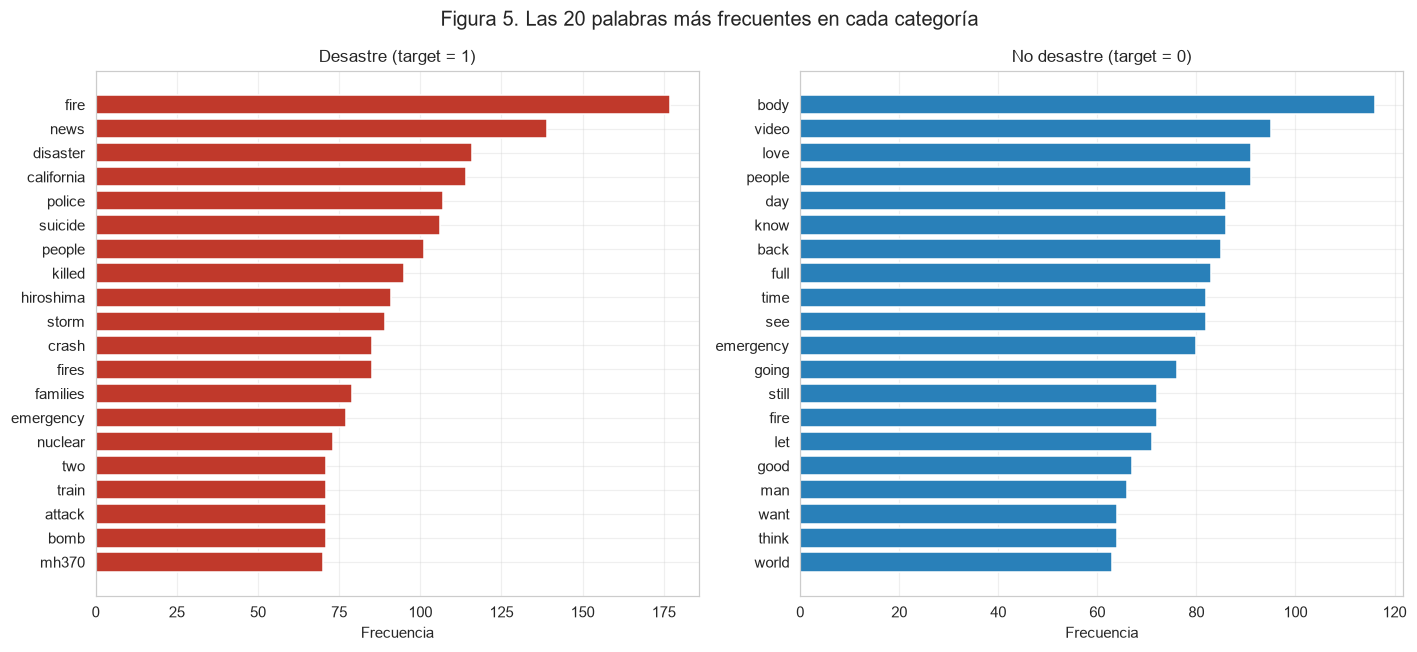

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, tgt, color in zip(axes, [1, 0], [config.COLOR_DESASTRE, config.COLOR_NO_DESASTRE]):
    comunes = frec[tgt].most_common(20)[::-1]
    palabras = [p for p, _ in comunes]
    valores = [v for _, v in comunes]
    ax.barh(palabras, valores, color=color)
    ax.set_title(f'{config.ETIQUETAS[tgt].capitalize()} (target = {tgt})', fontsize=11)
    ax.set_xlabel('Frecuencia')

fig.suptitle('Figura 5. Las 20 palabras más frecuentes en cada categoría', fontsize=13)
fig.tight_layout()
guardar(fig, 'eda_top_palabras_por_clase.png')
plt.show()

**Interpretación.** Las dos listas describen dos universos temáticos distintos.

En los tweets de **desastre real** la palabra más repetida es **`fire`**, y el resto del top
la acompaña con coherencia: `news`, `disaster`, `california`, `police`, `suicide`, `killed`,
`hiroshima`, `storm`, `crash`, `emergency`, `nuclear`. Es vocabulario de sucesos y de
cobertura periodística. Aparecen incluso eventos concretos: `california` y `hiroshima`
apuntan a episodios específicos presentes en el periodo de recolección.

En los tweets que **no** son de desastre la palabra más repetida es **`body`**, seguida de
`video`, `love`, `day`, `know`, `back`, `time`, `see`. Es vocabulario conversacional
cotidiano, sin tema común.

Que la palabra más frecuente de la clase negativa sea `body` merece atención: procede de
keywords como `body bag` y `body bags`, que el análisis de la sección 5.2 ya había situado
entre las menos asociadas a desastre real. Es un ejemplo perfecto del problema central del
laboratorio: **vocabulario de catástrofe empleado en sentido no literal**.

### 5.7 Nubes de palabras

El enunciado pide explícitamente una nube de palabras para visualizar los términos más
frecuentes. Se generan tres —global, desastre y no desastre— porque comparar las dos
categorías dice mucho más que mirar el conjunto entero.

figura guardada: eda_nube_global.png


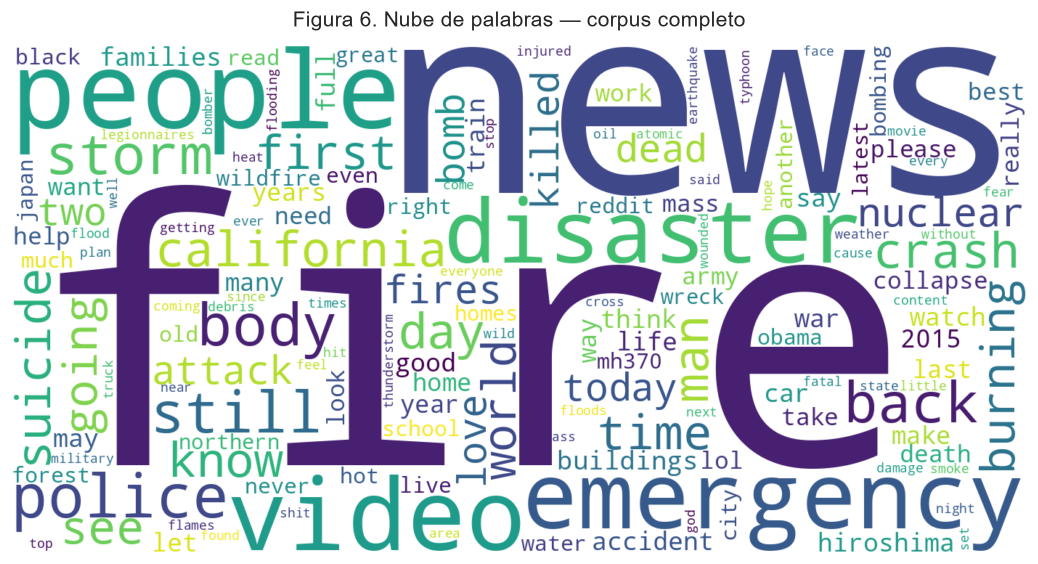

figura guardada: eda_nube_desastre.png


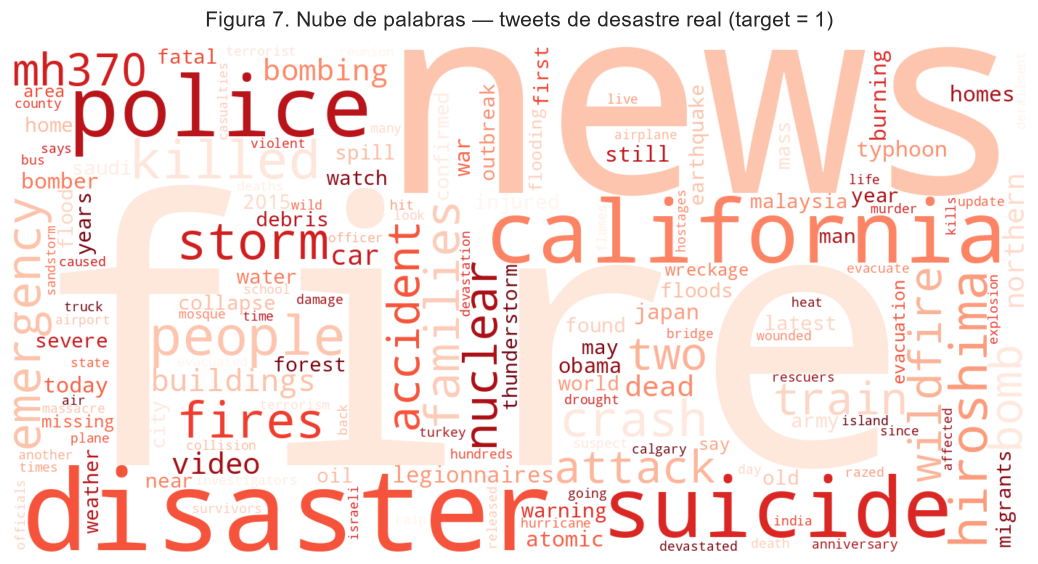

figura guardada: eda_nube_no_desastre.png


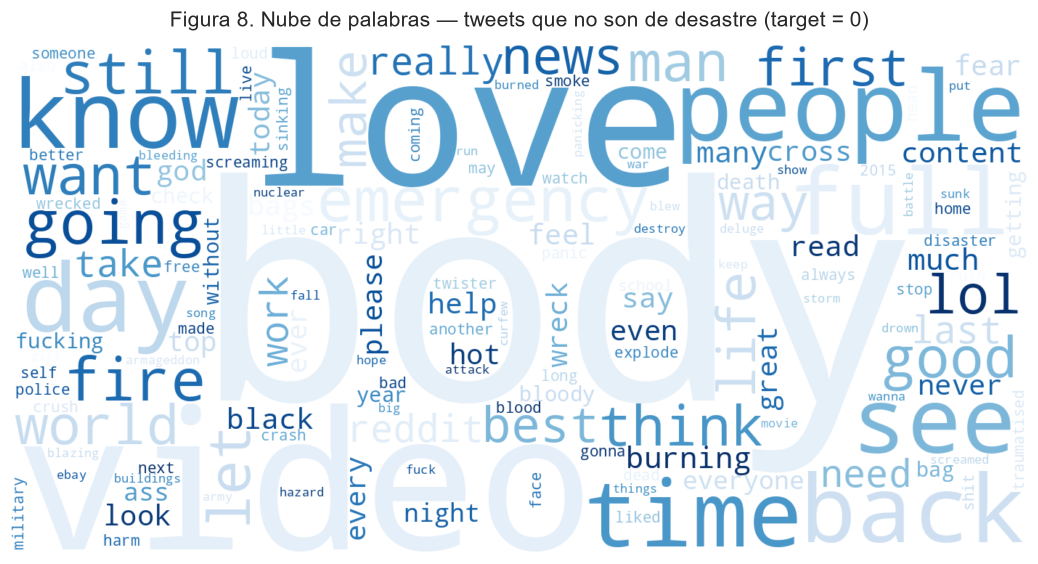

In [15]:
from wordcloud import WordCloud

def nube(contador, titulo, archivo, colormap):
    wc = WordCloud(width=1400, height=700, background_color='white',
                   colormap=colormap, max_words=150,
                   random_state=config.SEED).generate_from_frequencies(contador)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=14, pad=12)
    ax.grid(False)
    guardar(fig, archivo)
    plt.show()

frec_global = frec[0] + frec[1]

nube(frec_global, 'Figura 6. Nube de palabras — corpus completo',
     'eda_nube_global.png', 'viridis')
nube(frec[1], 'Figura 7. Nube de palabras — tweets de desastre real (target = 1)',
     'eda_nube_desastre.png', 'Reds')
nube(frec[0], 'Figura 8. Nube de palabras — tweets que no son de desastre (target = 0)',
     'eda_nube_no_desastre.png', 'Blues')

**Interpretación.** El contraste entre las Figuras 7 y 8 resume visualmente el problema.

La nube de **desastre real** está dominada por sustantivos concretos de suceso: `fire`,
`disaster`, `killed`, `storm`, `crash`, `emergency`, `nuclear`, `police`, junto a topónimos
como `california` e `hiroshima`. Es un campo semántico cerrado y reconocible.

La nube de **no desastre** es mucho más difusa: `body`, `video`, `love`, `day`, `know`,
`time`. No hay tema, porque no hay un tema común: la clase negativa se define por
**ausencia** —no habla de un desastre real— y eso incluye cualquier cosa.

Esa asimetría tiene una implicación para el ejercicio 6: **la clase positiva es más
"aprendible" que la negativa**. Un modelo puede reconocer el vocabulario de la catástrofe,
pero no puede reconocer "todo lo demás". Es esperable que los errores se concentren en
tweets de la clase negativa que emplean vocabulario de desastre en sentido figurado.

Nota metodológica: la nube de palabras es una herramienta de exploración, no de medición. El
tamaño de cada término refleja su frecuencia bruta, sin ponderar por lo informativo que sea.
Un término puede ser muy frecuente y no distinguir nada entre clases, que es exactamente lo
que se examina a continuación.

### 5.8 Palabras presentes en ambas categorías

El enunciado pide discutir las palabras que tienen presencia en todas las categorías. Son
importantes por una razón concreta: **una palabra frecuente en las dos clases no ayuda a
distinguirlas**, por mucho que destaque en una nube de palabras.

In [16]:
top40_d = {p for p, _ in frec[1].most_common(40)}
top40_n = {p for p, _ in frec[0].most_common(40)}
compartidas = sorted(top40_d & top40_n)

print(f'Palabras en el top 40 de AMBAS categorías: {len(compartidas)}')
print(compartidas)
print()

total_d, total_n = sum(frec[1].values()), sum(frec[0].values())
filas = []
for p in compartidas:
    f_d, f_n = frec[1][p], frec[0][p]
    filas.append({
        'palabra': p,
        'frec_desastre': f_d,
        'frec_no_desastre': f_n,
        'p_desastre': f_d / total_d,
        'p_no_desastre': f_n / total_n,
        'log_ratio': np.log((f_d / total_d) / (f_n / total_n)),
    })

comp = pd.DataFrame(filas).set_index('palabra').sort_values('log_ratio')
comp[['p_desastre', 'p_no_desastre']] = comp[['p_desastre', 'p_no_desastre']].round(5)
comp['log_ratio'] = comp.log_ratio.round(3)
guardar_tabla(comp, 'eda_palabras_compartidas.csv')
comp

Palabras en el top 40 de AMBAS categorías: 7
['burning', 'emergency', 'fire', 'news', 'people', 'still', 'video']

tabla guardada: eda_palabras_compartidas.csv


,frec_desastre,frec_no_desastre,p_desastre,p_no_desastre,log_ratio
palabra,,,,,
video,65,95,0.00228,0.00285,-0.223
still,56,72,0.00197,0.00216,-0.095
emergency,77,80,0.00271,0.00240,0.118
burning,55,52,0.00193,0.00156,0.213
people,101,91,0.00355,0.00273,0.261
news,139,58,0.00489,0.00174,1.031
fire,177,72,0.00622,0.00216,1.056


**Interpretación.** Siete palabras aparecen en el top 40 de las dos categorías: `burning`,
`emergency`, `fire`, `news`, `people`, `still` y `video`. La columna `log_ratio` mide hacia
qué clase se inclina cada una: un valor cercano a 0 significa que la palabra se reparte casi
por igual y por tanto **no aporta capacidad de discriminación**.

Conviene separarlas en dos grupos, porque no todas las palabras compartidas son iguales:

- **Compartidas y poco informativas**, con log-ratio cercano a cero: `people`, `still`,
  `burning`. Son frecuentes en ambos lados y funcionan como ruido de fondo del dominio. Son
  candidatas naturales a **stopwords específicas de esta colección**, además de la lista
  estándar del inglés, siguiendo la recomendación del material del curso de ajustar la lista
  a la colección concreta.
- **Compartidas pero aun así informativas**, con log-ratio apreciable: `fire`, `news` y
  `emergency` se inclinan hacia desastre, mientras que `video` se inclina hacia no desastre.
  Aparecen en ambas clases, pero no en la misma proporción. **Estas no deben eliminarse**:
  su frecuencia bruta engaña, y solo la comparación entre clases revela que sí aportan.

La lección metodológica es que **frecuencia e informatividad son cosas distintas**. Es
exactamente el problema que TF-IDF resuelve al penalizar los términos presentes en muchos
documentos, y la razón por la que el ejercicio 4 debe apoyarse en medidas relativas entre
clases y no solo en conteos. El análisis riguroso, con suavizado y extendido a bigramas y
trigramas, corresponde a ese ejercicio.

## Síntesis: qué se lleva el resto del laboratorio

El análisis exploratorio deja conclusiones concretas y accionables, no solo descripciones.

**Sobre los datos**

1. Quedan **7,485 tweets** tras eliminar 128 filas duplicadas o con etiquetas
   contradictorias. Los 18 textos con anotación contradictoria son evidencia de que la
   tarea es genuinamente ambigua incluso para anotadores humanos.
2. El desbalance es moderado (57.41% / 42.59%). Un clasificador trivial alcanza 57.41% de
   exactitud, así que **la métrica de selección debe ser macro-F1**.

**Decisiones para el preprocesamiento (ejercicio 3)**

3. **Las URLs deben reemplazarse por un token uniforme, no borrarse.** Su presencia es el
   patrón más discriminativo del conjunto (67.35% frente a 41.73%), aunque su texto sea ruido.
4. **Los números no deben eliminarse a ciegas.** Aparecen en el 72.74% de los tweets de
   desastre frente al 49.90% del resto. El caso del `911` que sugiere el enunciado es
   anecdótico —solo 4 tweets—, pero los dígitos en general sí son señal.
5. **Hay que limpiar el mojibake**, presente en el 7.90% de los tweets. En cambio el
   tratamiento de emoticones es irrelevante aquí: no hay emojis Unicode y los emoticones
   ASCII aparecen en menos del 1% de los casos.
6. Las **stopwords específicas del dominio** deberían incluir `people`, `still` y `burning`,
   pero **no** `fire`, `news`, `emergency` ni `video`, que sí discriminan.

**Decisiones para el modelado (ejercicios 6 y 10)**

7. **`keyword` debe incorporarse como característica.** Es la variable estructurada más
   informativa: algunas keywords son deterministas en ambos sentidos.
8. **`location` se descarta**, con la evidencia del 33% de nulos y 3,321 valores sin
   normalizar.
9. Los errores del clasificador deberían concentrarse en el **uso figurado del lenguaje de
   catástrofe** (`aftershock`, `body bag`, `ruin`). Es una hipótesis verificable en el
   análisis de errores del ejercicio 6.
10. Los tweets de desastre son **más factuales y menos emocionales** que los demás: menos
    exclamaciones y menos menciones. Eso anticipa que una variable de sentimiento podría
    aportar poco al ejercicio 10, algo que ese ejercicio deberá comprobar en lugar de
    suponer.